In [15]:
%config InlineBackend.figure_formats = ['svg']
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('_data/coding-time_*/*/coding-time.csv')]
data = pd.concat(frames, ignore_index=True)
data['inner_code'] = data.apply(lambda r: f'({r["fragment_n"]}, {r["fragment_k"]})', axis=1)
data['outer_code'] = data.apply(lambda r: f'({r["chunk_n"]}, {r["chunk_k"]})', axis=1)
data['code'] = data.apply(lambda r: f'({r["chunk_n"]}, {r["chunk_k"]}) ({r["fragment_n"]}, {r["fragment_k"]})', axis=1)
data['Operation'] = data['op']
data

,chunk_k,chunk_n,fragment_k,fragment_n,op,time,inner_code,outer_code,code,Operation
0,4,5,32,80,encode,15.526209,"(80, 32)","(5, 4)","(5, 4) (80, 32)",encode
1,4,5,32,80,decode,13.410371,"(80, 32)","(5, 4)","(5, 4) (80, 32)",decode
2,4,5,32,80,repair,1.099703,"(80, 32)","(5, 4)","(5, 4) (80, 32)",repair
3,8,10,32,80,encode,15.108065,"(80, 32)","(10, 8)","(10, 8) (80, 32)",encode
4,8,10,32,80,decode,11.737901,"(80, 32)","(10, 8)","(10, 8) (80, 32)",decode
...,...,...,...,...,...,...,...,...,...,...
175,8,10,32,80,decode,11.913918,"(80, 32)","(10, 8)","(10, 8) (80, 32)",decode
176,8,10,32,80,repair,0.515444,"(80, 32)","(10, 8)","(10, 8) (80, 32)",repair
177,8,10,48,120,encode,15.527419,"(120, 48)","(10, 8)","(10, 8) (120, 48)",encode
178,8,10,48,120,decode,11.847760,"(120, 48)","(10, 8)","(10, 8) (120, 48)",decode


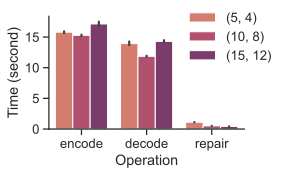

In [32]:
# palette = sns.color_palette('flare', n_colors=5)
f = (
    sns.catplot(
        kind="bar",
        data=data[data["fragment_n"] == 80],
        # order=["(5, 4) (80, 32)", "(10, 8) (80, 32)", "(15, 12) (80, 32)"],
        # x="code", y="time", hue="Operation",
        # data=data,
        x="Operation",
        y="time",
        hue="outer_code",
        # hue_order=["(5, 4) (80, 32)", "(10, 8) (80, 32)", "(15, 12) (80, 32)"],
        palette="flare",
        height=2.56,
        aspect=1.5,
    )
    .set_xlabels("Operation")
    .set_ylabels("Time (second)")
)
sns.move_legend(f, "center", bbox_to_anchor=(0.7, 0.8), title=None, frameon=False)
f.savefig("coding-time-outer.pdf")

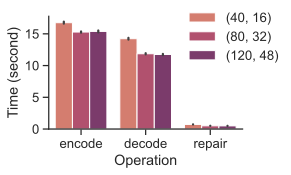

In [35]:
f = (
    sns.catplot(
        data=data[data["chunk_n"] == 10],
        kind="bar",
        # order=["(10, 8) (40, 16)", "(10, 8) (80, 32)", "(10, 8) (120, 48)"],
        # x="code", y="time", hue="Operation",
        x="Operation",
        y="time",
        hue="inner_code",
        # hue_order=["(10, 8) (40, 16)", "(10, 8) (80, 32)", "(10, 8) (120, 48)"],
        hue_order=["(40, 16)", "(80, 32)", "(120, 48)"],
        palette="flare",
        height=2.56,
        aspect=1.5,
    )
    .set_xlabels("Operation")
    .set_ylabels("Time (second)")
)
sns.move_legend(f, "center", bbox_to_anchor=(0.7, 0.8), title=None, frameon=False)
f.savefig("coding-time-inner.pdf")